In [30]:
from pathlib import Path
import yaml

import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns

import yfinance as yf

In [31]:

from time_series_forecasting.data.ingestion.yahoo_finance import (
    load_yahoo_finance_data
)

In [32]:
stock = "AAPL"
start_date = '2022-01-01'
end_date = '2025-01-30'

data = load_yahoo_finance_data(stock, start_date, end_date)
data.head()

,Adj Close,Close,High,Low,Open,Volume
date,,,,,,
2022-01-03,178.270309,182.009995,182.880005,177.710007,177.830002,104487900
2022-01-04,176.007767,179.699997,182.940002,179.119995,182.630005,99310400
2022-01-05,171.326004,174.919998,180.169998,174.639999,179.610001,94537600
2022-01-06,168.466019,172.000000,175.300003,171.639999,172.699997,96904000
2022-01-07,168.632507,172.169998,174.139999,171.029999,172.889999,86709100


---

In [33]:
data.reset_index()  

,date,Adj Close,Close,High,Low,Open,Volume
0,2022-01-03,178.270309,182.009995,182.880005,177.710007,177.830002,104487900
1,2022-01-04,176.007767,179.699997,182.940002,179.119995,182.630005,99310400
2,2022-01-05,171.326004,174.919998,180.169998,174.639999,179.610001,94537600
3,2022-01-06,168.466019,172.000000,175.300003,171.639999,172.699997,96904000
4,2022-01-07,168.632507,172.169998,174.139999,171.029999,172.889999,86709100
...,...,...,...,...,...,...,...
766,2025-01-23,222.653015,223.660004,227.029999,222.300003,224.740005,60234800
767,2025-01-24,221.776947,222.779999,225.630005,221.410004,224.779999,54697900
768,2025-01-27,228.825089,229.860001,232.149994,223.979996,224.020004,94863400
769,2025-01-28,237.187256,238.259995,240.190002,230.809998,230.850006,75707600


/opt/miniconda3/envs/ts-forecast/lib/python3.10/site-packages/mplfinance/_arg_validators.py:84: UserWarning: 


            POSSIBLE TO SEE DETAILS (Candles, Ohlc-Bars, Etc.)
   For more information see:
   - https://github.com/matplotlib/mplfinance/wiki/Plotting-Too-Much-Data
   
   TO SILENCE THIS WARNING, set `type='line'` in `mpf.plot()`
   OR set kwarg `warn_too_much_data=N` where N is an integer 
   LARGER than the number of data points you want to plot.

  warnings.warn('\n\n ================================================================= '+


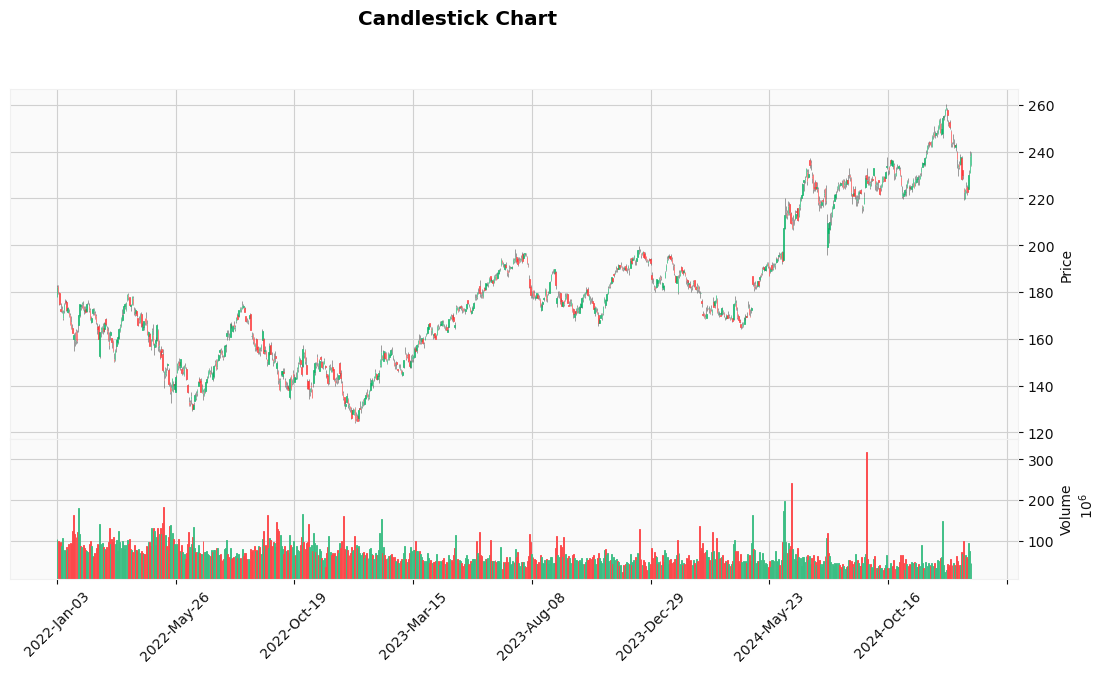

In [34]:
import mplfinance as mpf

mpf.plot(
    data,
    type="candle",
    volume=True,
    style="yahoo",
    title="Candlestick Chart",
    ylabel="Price",
    ylabel_lower="Volume",
    figsize=(14, 7)
)

/opt/miniconda3/envs/ts-forecast/lib/python3.10/site-packages/mplfinance/_arg_validators.py:84: UserWarning: 


            POSSIBLE TO SEE DETAILS (Candles, Ohlc-Bars, Etc.)
   For more information see:
   - https://github.com/matplotlib/mplfinance/wiki/Plotting-Too-Much-Data
   
   TO SILENCE THIS WARNING, set `type='line'` in `mpf.plot()`
   OR set kwarg `warn_too_much_data=N` where N is an integer 
   LARGER than the number of data points you want to plot.

  warnings.warn('\n\n ================================================================= '+


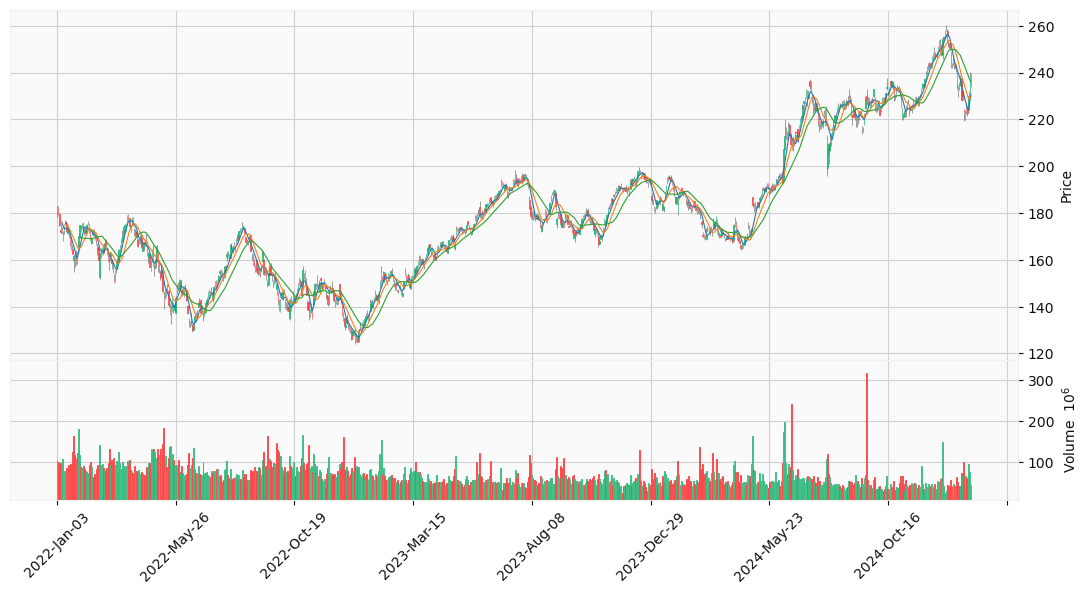

In [35]:
mpf.plot(
    data,
    type="candle",
    mav=(5, 10, 20),
    volume=True,
    style="yahoo",
    figsize=(14, 7)
)


In [36]:
df = data.reset_index()[["date", "Close"]]
df

,date,Close
0,2022-01-03,182.009995
1,2022-01-04,179.699997
2,2022-01-05,174.919998
3,2022-01-06,172.000000
4,2022-01-07,172.169998
...,...,...
766,2025-01-23,223.660004
767,2025-01-24,222.779999
768,2025-01-27,229.860001
769,2025-01-28,238.259995


<Axes: xlabel='date'>

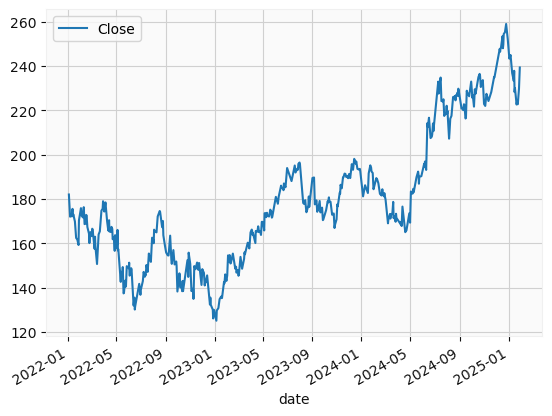

In [37]:
df.plot(kind = 'line', x = 'date', y = 'Close')

In [45]:
from __future__ import annotations

from typing import Optional, Sequence
import pandas as pd
import mplfinance as mpf


def plot_candlestick(
    df: pd.DataFrame,
    *,
    title: str = "Candlestick Chart",
    style: str = "yahoo",
    volume: bool = True,
    figsize: tuple[int, int] = (14, 7),

    # ---- Overlay options ----
    show_close_line: bool = False,
    sma_windows: Optional[Sequence[int]] = None,
    ema_windows: Optional[Sequence[int]] = None,
    forecast: Optional[pd.Series] = None,

    # ---- Indicator panels ----
    show_rsi: bool = False,
    rsi_window: int = 14,
    show_macd: bool = False,
) -> None:
    """
    Enterprise-grade candlestick chart with overlays & indicators.
    SAFE against mplfinance length mismatch bugs.
    """

    # ==========================================================
    # 1️⃣ Validation
    # ==========================================================
    required_cols = {"Open", "High", "Low", "Close"}
    missing = required_cols - set(df.columns)
    if missing:
        raise ValueError(f"Missing required OHLC columns: {missing}")

    if not isinstance(df.index, pd.DatetimeIndex):
        raise TypeError("DataFrame index must be a DatetimeIndex")

    df = df.sort_index().copy()

    add_plots = []
    panel_count = 1  # panel 0 = price

    # ==========================================================
    # 2️⃣ Close overlay
    # ==========================================================
    if show_close_line:
        add_plots.append(
            mpf.make_addplot(
                df["Close"],
                panel=0,
                color="blue",
                width=1.2,
                secondary_y=False,
            )
        )

    # ==========================================================
    # 3️⃣ SMA overlays
    # ==========================================================
    if sma_windows:
        for window in sma_windows:
            sma = df["Close"].rolling(window, min_periods=window).mean()
            add_plots.append(
                mpf.make_addplot(
                    sma,
                    panel=0,
                    width=1,
                    label=f"SMA {window}",
                    secondary_y=False,
                )
            )

    # ==========================================================
    # 4️⃣ EMA overlays
    # ==========================================================
    if ema_windows:
        for window in ema_windows:
            ema = df["Close"].ewm(span=window, adjust=False).mean()
            add_plots.append(
                mpf.make_addplot(
                    ema,
                    panel=0,
                    width=1,
                    linestyle="--",
                    label=f"EMA {window}",
                    secondary_y=False,
                )
            )

    # ==========================================================
    # 5️⃣ Forecast overlay
    # ==========================================================
    if forecast is not None:
        if not forecast.index.equals(df.index):
            raise ValueError("Forecast index must match df.index")

        add_plots.append(
            mpf.make_addplot(
                forecast,
                panel=0,
                color="orange",
                linestyle="--",
                width=2,
                label="Forecast",
                secondary_y=False,
            )
        )

    # ==========================================================
    # 6️⃣ RSI panel (FULL LENGTH — SAFE)
    # ==========================================================
    if show_rsi:
        delta = df["Close"].diff()
        gain = delta.clip(lower=0)
        loss = -delta.clip(upper=0)

        avg_gain = gain.rolling(rsi_window, min_periods=rsi_window).mean()
        avg_loss = loss.rolling(rsi_window, min_periods=rsi_window).mean()

        rs = avg_gain / avg_loss
        rsi = 100 - (100 / (1 + rs))  # KEEP FULL LENGTH

        add_plots.append(
            mpf.make_addplot(
                rsi,
                panel=panel_count,
                ylabel="RSI",
                color="purple",
                secondary_y=False,
            )
        )
        panel_count += 1

    # ==========================================================
    # 7️⃣ MACD panel (FULL LENGTH — SAFE)
    # ==========================================================
    if show_macd:
        ema_12 = df["Close"].ewm(span=12, adjust=False).mean()
        ema_26 = df["Close"].ewm(span=26, adjust=False).mean()

        macd = ema_12 - ema_26
        signal = macd.ewm(span=9, adjust=False).mean()
        hist = macd - signal

        add_plots.extend([
            mpf.make_addplot(
                macd,
                panel=panel_count,
                color="blue",
                ylabel="MACD",
                secondary_y=False,
            ),
            mpf.make_addplot(
                signal,
                panel=panel_count,
                color="red",
                secondary_y=False,
            ),
            mpf.make_addplot(
                hist,
                type="bar",
                panel=panel_count,
                color="gray",
                alpha=0.4,
                secondary_y=False,
            ),
        ])
        panel_count += 1

    # ==========================================================
    # 8️⃣ Render
    # ==========================================================
    mpf.plot(
        df,
        type="candle",
        volume=volume,
        style=style,
        addplot=add_plots if add_plots else None,
        title=title,
        figsize=figsize,
        panel_ratios=[3] + [1] * (panel_count - 1),
    )


/opt/miniconda3/envs/ts-forecast/lib/python3.10/site-packages/mplfinance/_arg_validators.py:84: UserWarning: 


            POSSIBLE TO SEE DETAILS (Candles, Ohlc-Bars, Etc.)
   For more information see:
   - https://github.com/matplotlib/mplfinance/wiki/Plotting-Too-Much-Data
   
   TO SILENCE THIS WARNING, set `type='line'` in `mpf.plot()`
   OR set kwarg `warn_too_much_data=N` where N is an integer 
   LARGER than the number of data points you want to plot.

  warnings.warn('\n\n ================================================================= '+


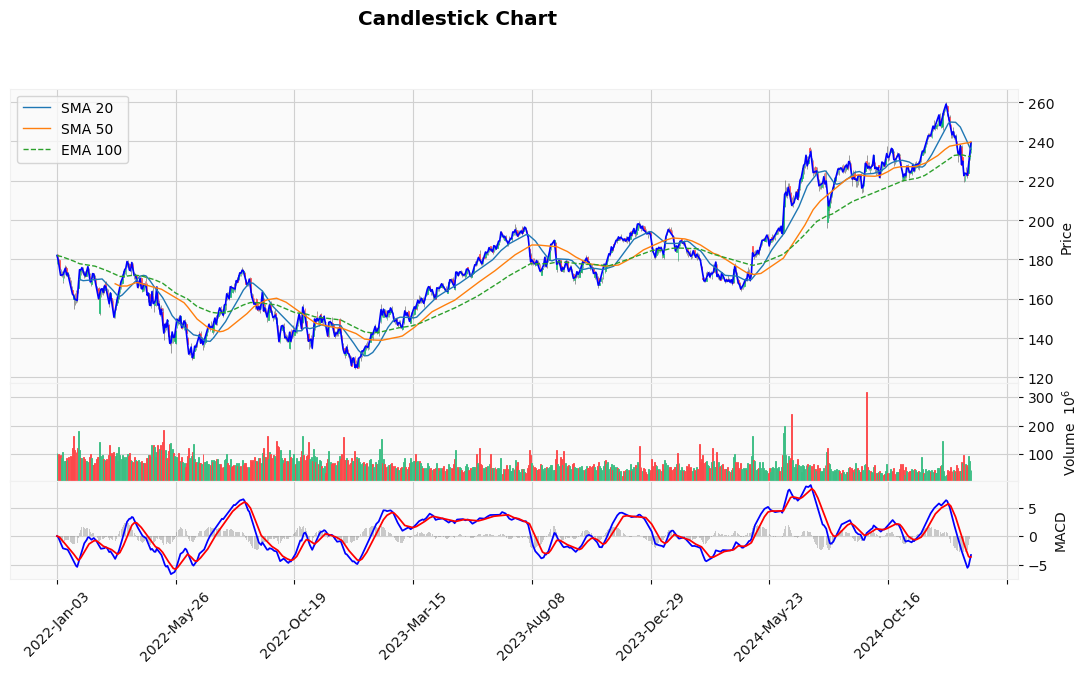

In [46]:
plot_candlestick(
    data,
    show_close_line=True,
    sma_windows=[20, 50],
    ema_windows=[100],
    show_rsi=True,
    show_macd=True,
)


---
---

### Clasical Time-Series Decomposition

In [47]:
from statsmodels.tsa.seasonal import seasonal_decompose

In [60]:
def decompose_classical(data: pd.DataFrame, feature: str, *, period: int = 30, model: str = 'additive') -> dict[str, pd.DataFrame]:
    result = seasonal_decompose(
        data[feature], 
        model = model, 
        period = period,
        extrapolate_trend = "freq"
    )
    return {
        "observed": result.observed,
        "trend": result.trend,
        "seasonal": result.seasonal,
        'residual': result.resid
    }

In [61]:
def plot_decompose_classical(components: dict[str, pd.DataFrame]) -> None:
    figure, axes = plt.subplots(
        nrows = len(components),
        ncols = 1,
        sharex = True,
        figsize = (10, 2 * len(components))
    )

    for axis, (name, component) in zip(axes, components.items()):
        axis.plot(component, label = name, linewidth = 1.5)
        axis.legend()
        axis.set_title(name)
    
    figure.tight_layout()
    plt.show()
    


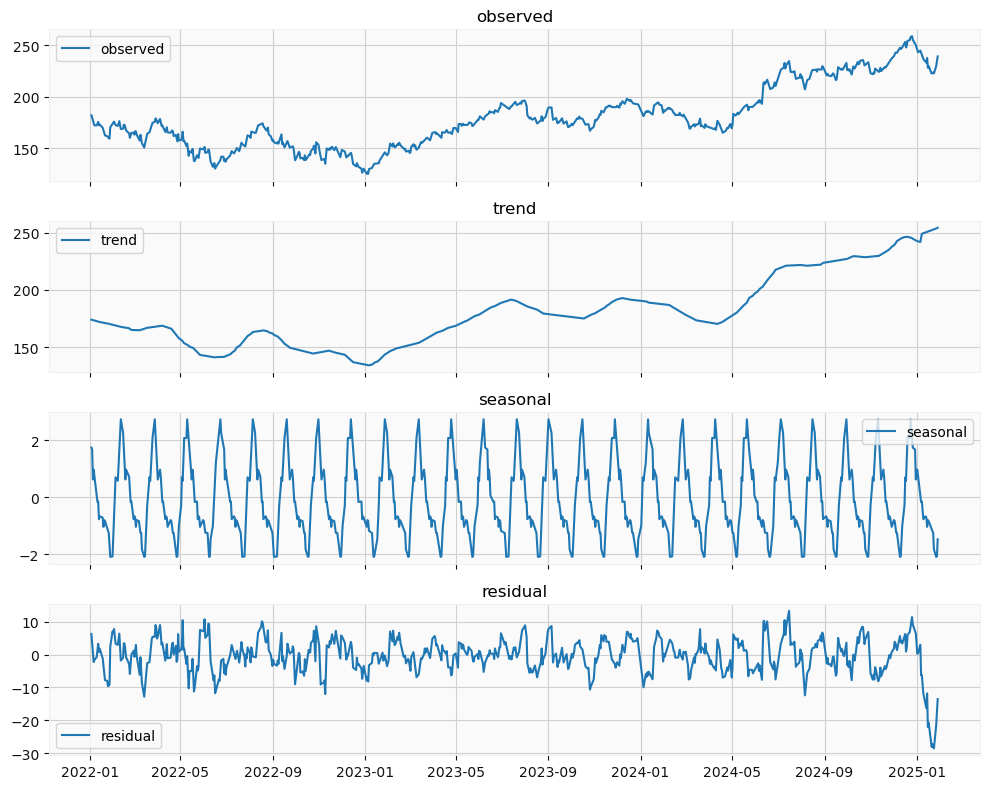

In [62]:
plot_decompose_classical(
    components=decompose_classical(
        data = data,
        feature="Close",

    )
)

In [76]:
def seasonal_boxplots(components: dict) -> plt.Figure:
    """
    Boxplots of decomposition components.
    """
    order = ["seasonal", "trend", "residual", "observed"]

    fig, axes = plt.subplots(
        nrows=len(order),
        ncols=1,
        figsize=(12, 8),
        constrained_layout=True,
    )

    for ax, key in zip(axes, order):
        series = components[key].dropna()
        ax.boxplot(series, vert=True)
        ax.set_title(key.capitalize())
        ax.grid(True, alpha=0.3)

    return fig


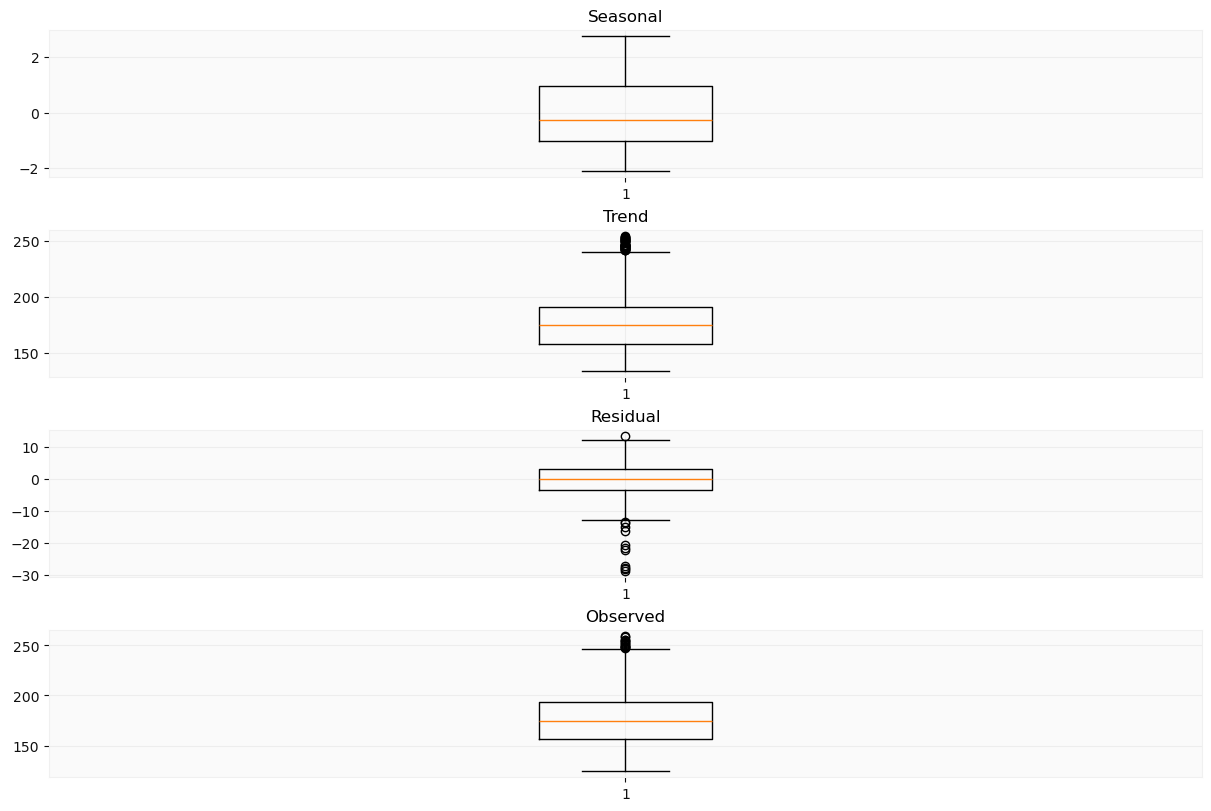

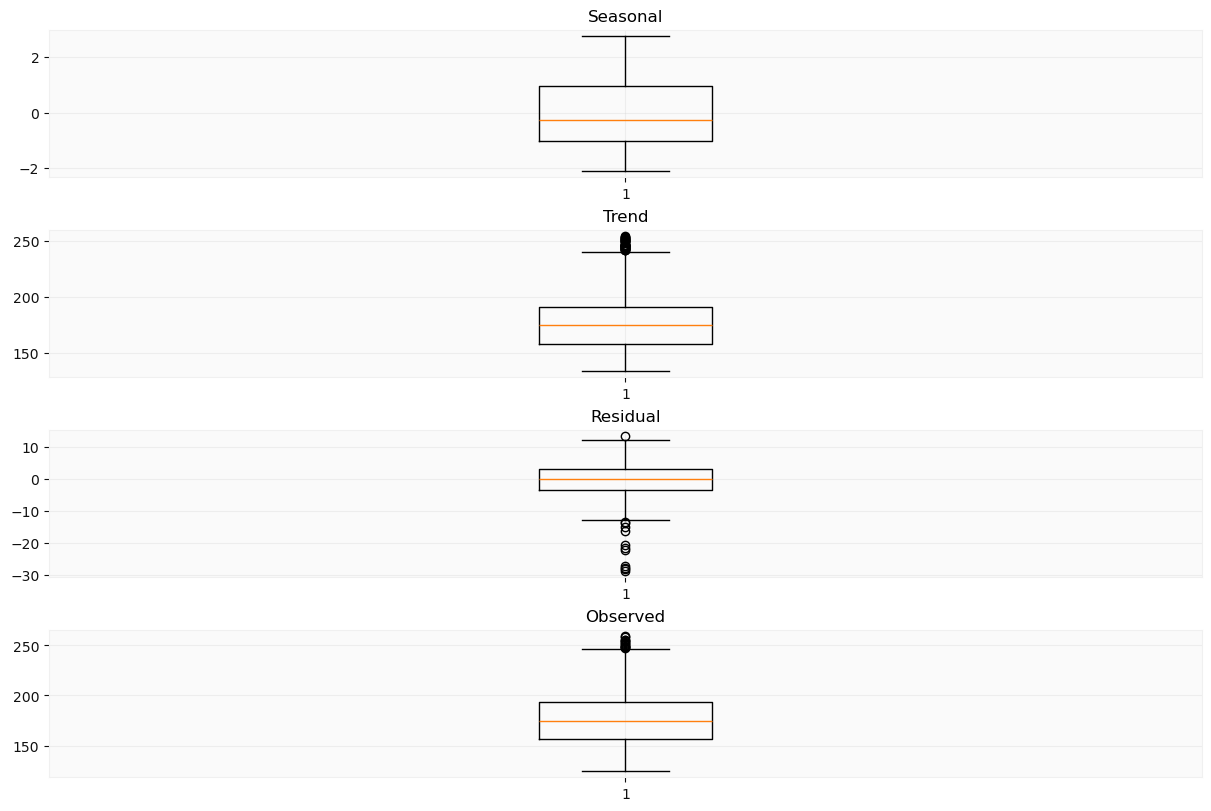

In [77]:
components = decompose_classical(data=data, feature="Close")
seasonal_boxplots(components)


In [78]:
import seaborn as sns

def seasonal_boxplots_seaborn(components: dict) -> plt.Figure:
    order = ["seasonal", "trend", "residual", "observed"]

    fig, axes = plt.subplots(
        len(order), 1,
        figsize=(12, 8),
        constrained_layout=True,
    )

    for ax, key in zip(axes, order):
        sns.boxplot(
            y=components[key].dropna(),
            ax=ax,
        )
        ax.set_title(key.capitalize())
        ax.set_ylabel("")
        ax.grid(True, alpha=0.3)

    return fig


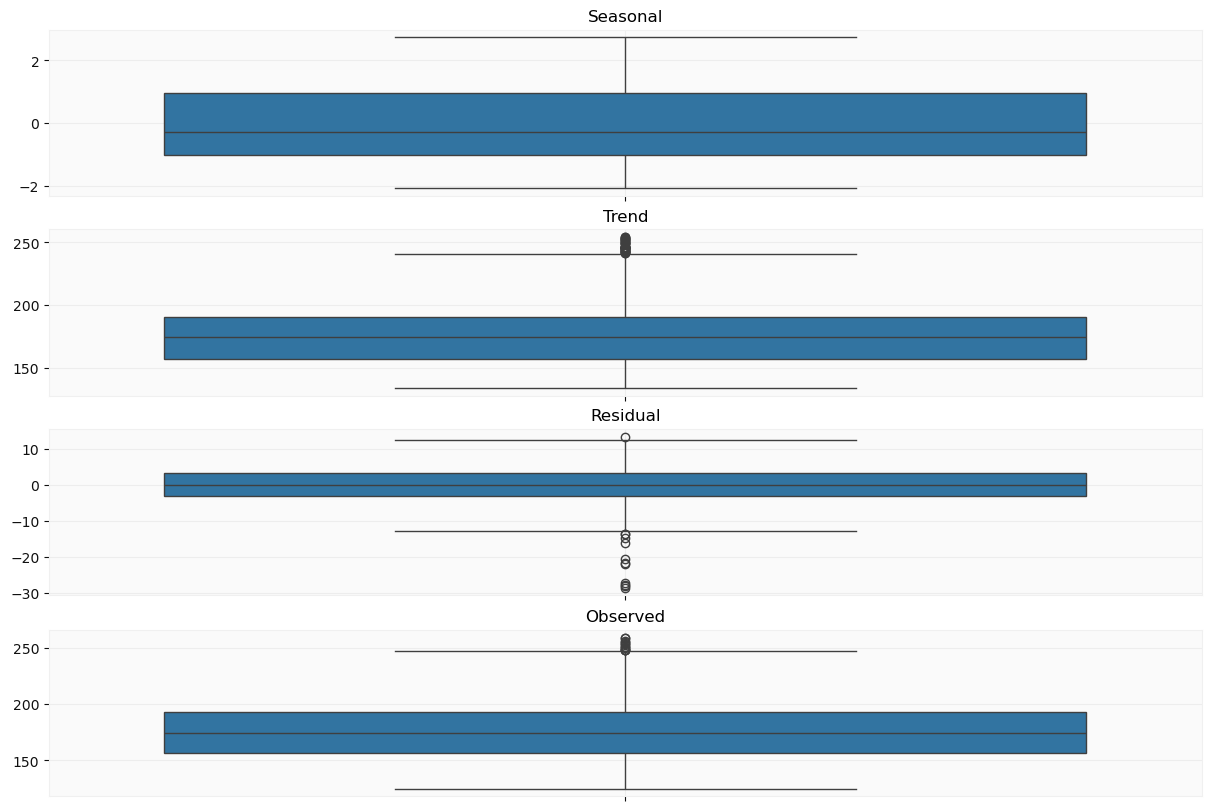

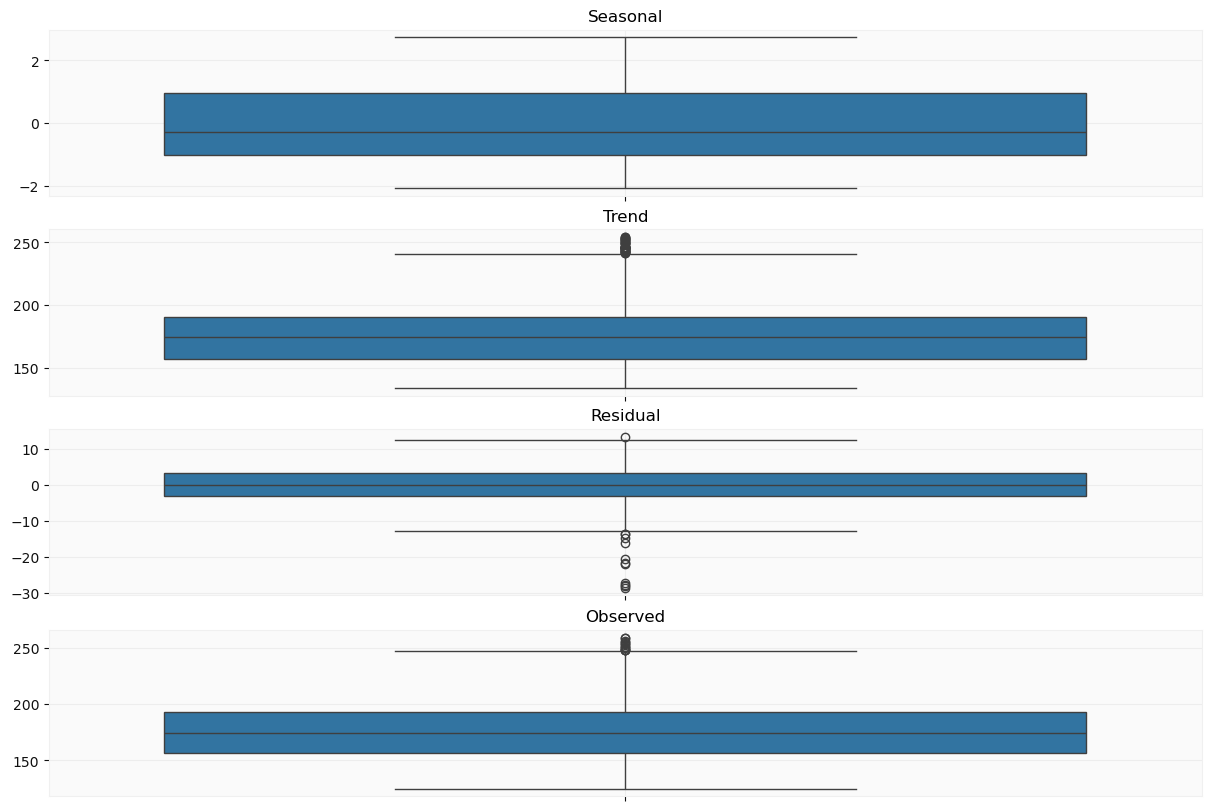

In [80]:
components = decompose_classical(data=data, feature="Close")
seasonal_boxplots_seaborn(components)

## STL decomposition

In [91]:
from statsmodels.tsa.seasonal import STL

In [92]:
stl = STL(data['Close'], period = 30)
result = stl.fit()

In [93]:
result.observed

date
2022-01-03    182.009995
2022-01-04    179.699997
2022-01-05    174.919998
2022-01-06    172.000000
2022-01-07    172.169998
                 ...    
2025-01-23    223.660004
2025-01-24    222.779999
2025-01-27    229.860001
2025-01-28    238.259995
2025-01-29    239.360001
Name: Close, Length: 771, dtype: float64

In [94]:
plot_decompose_classical(result
)

TypeError: object of type 'DecomposeResult' has no len()

In [96]:
def classical_decompose(data, feature, model, period):
    match model:
        case "additive":
            result = seasonal_decompose(data[feature], model="additive", period=period, extrapolate_trend = "freq")
        case "multiplicative":
            result = seasonal_decompose(data[feature], model="multiplicative", period=period, extrapolate_trend = "freq")
        case "stl":
            stl = STL(data[feature], period=period, robust=True, extrapolate_trend = "freq")
            result = stl.fit()
        case _:
            raise ValueError("Invalid model")
    
    return {
        "observed": result.observed,
        "trend": result.trend,
        "seasonal": result.seasonal,
        'residual': result.resid
    }

### Registry / Dispatch Pattern (Industry Standard)

In [97]:
from statsmodels.tsa.seasonal import seasonal_decompose, STL

def _additive(series, period):
    return seasonal_decompose(
        series, 
        model="additive", 
        period=period, 
        extrapolate_trend = "freq"
    )

def _multiplicative(series, period):
    return seasonal_decompose(
        series, 
        model="multiplicative", 
        period=period, 
        extrapolate_trend = "freq"
    )

def _stl(series, period):
    return STL(
        series, 
        period=period, 
        robust=True, 
    ).fit()

_DECOMPOSE_REGISTRY = {
    "additive": _additive,
    "multiplicative": _multiplicative,
    "stl": _stl,
}

def classical_decompose(data, feature, model, period):
    try:
        decompose_fn = _DECOMPOSE_REGISTRY[model]
    except KeyError:
        raise ValueError(
            f"Invalid Model: '{model}'."
            f"Choose model from {list(_DECOMPOSE_REGISTRY.keys())}"
        )
    result = decompose_fn(data[feature], period)
    return {
        'observed': result.observed,
        'trend': result.trend,
        'seasonal': result.seasonal,
        'residual': result.resid,   
    }

        

In [109]:
decompose_additive = classical_decompose(data, feature="Close", model="additive", period=30)
decompose_multiplicative = classical_decompose(data, feature="Close", model="multiplicative", period=30)
decompose_stl = classical_decompose(data, feature="Close", model="stl", period=30)


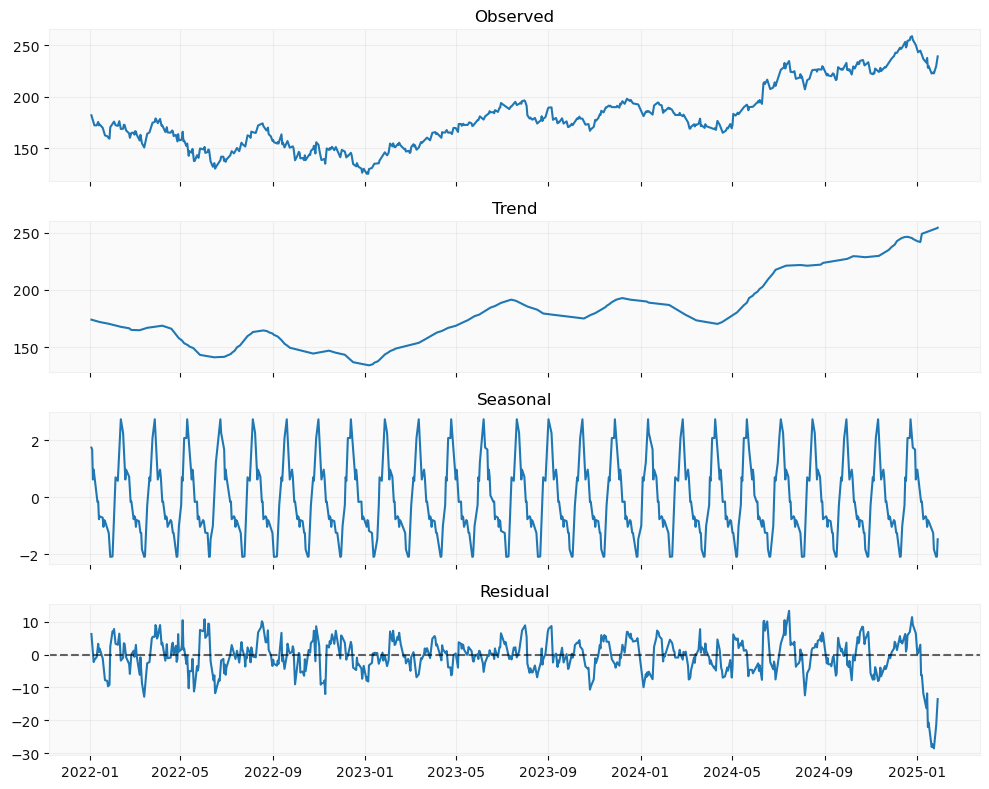

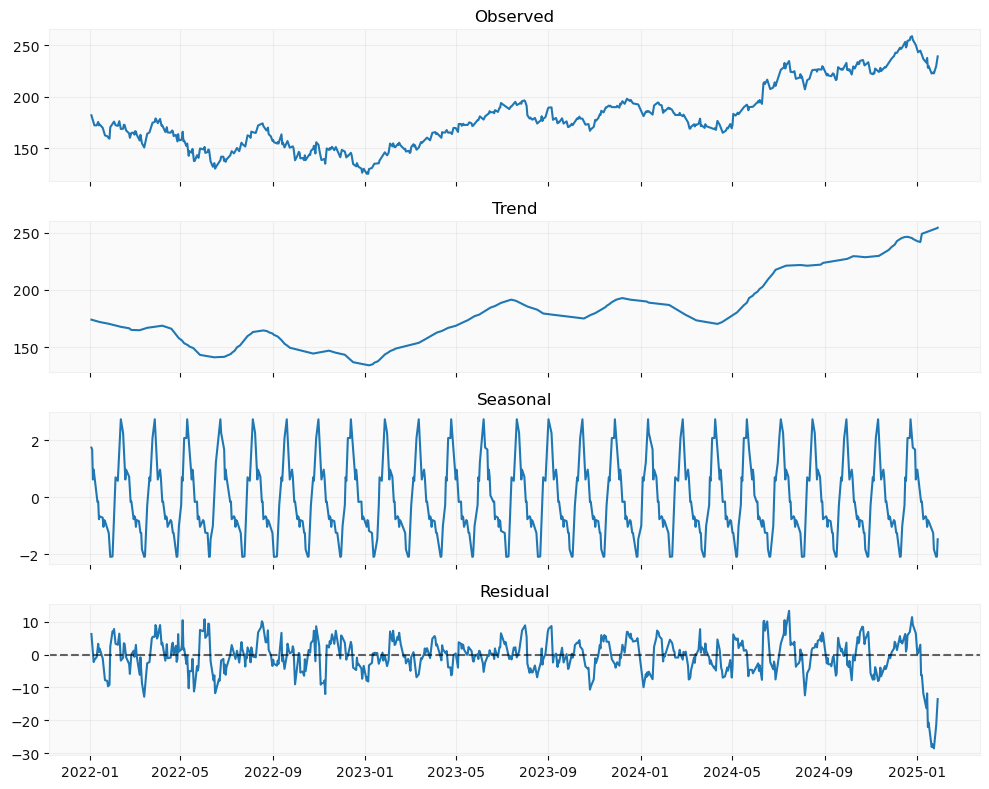

In [111]:
plot_decompose_classical(decompose_additive)

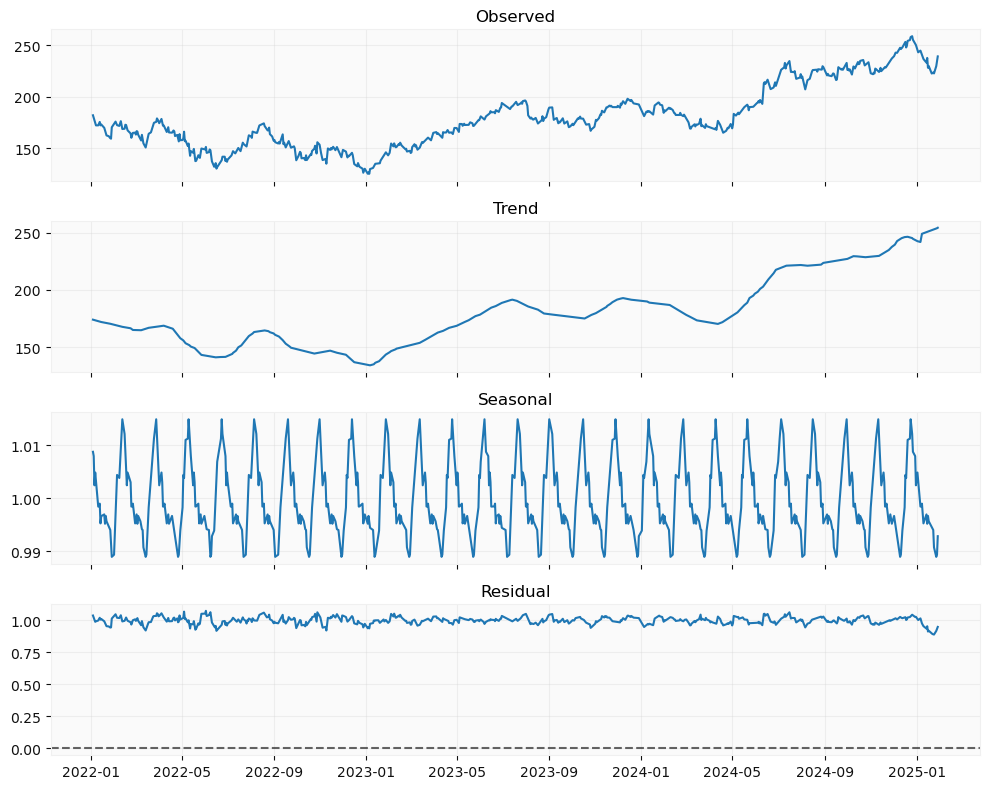

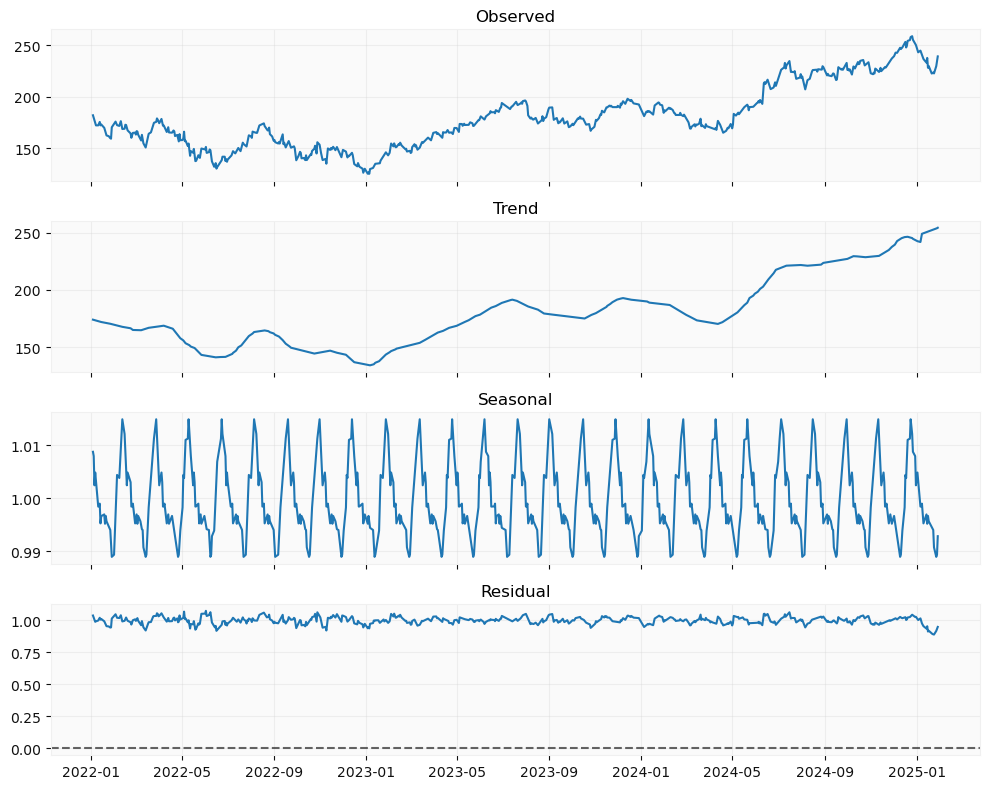

In [112]:
plot_decompose_classical(decompose_multiplicative)

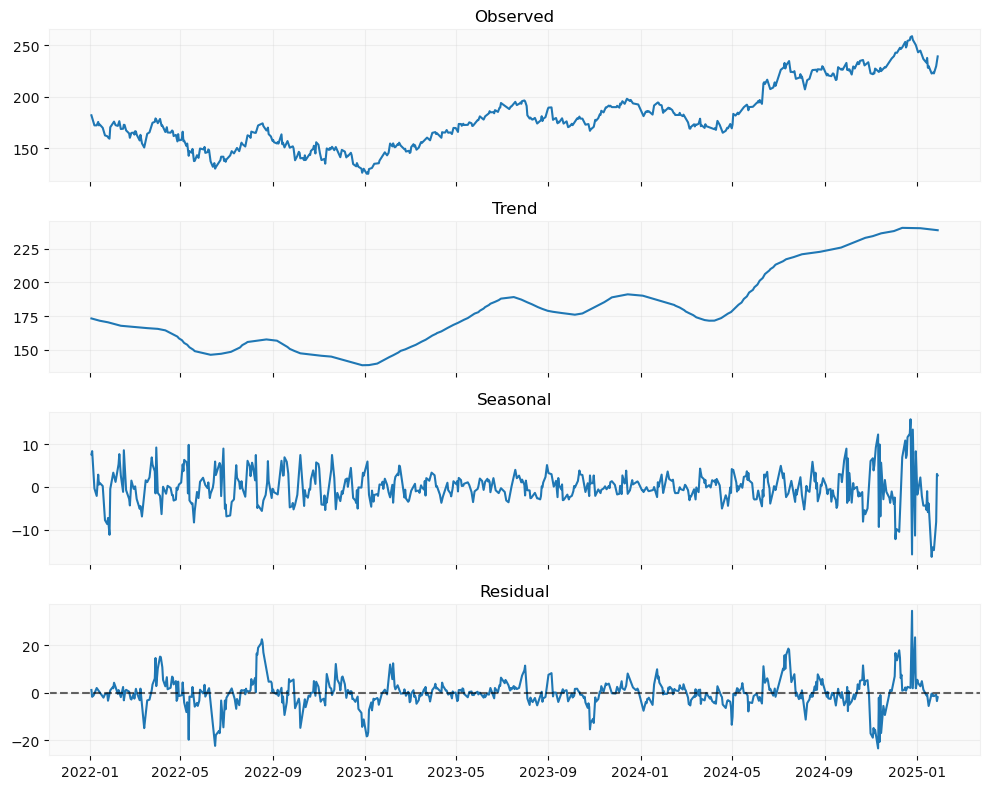

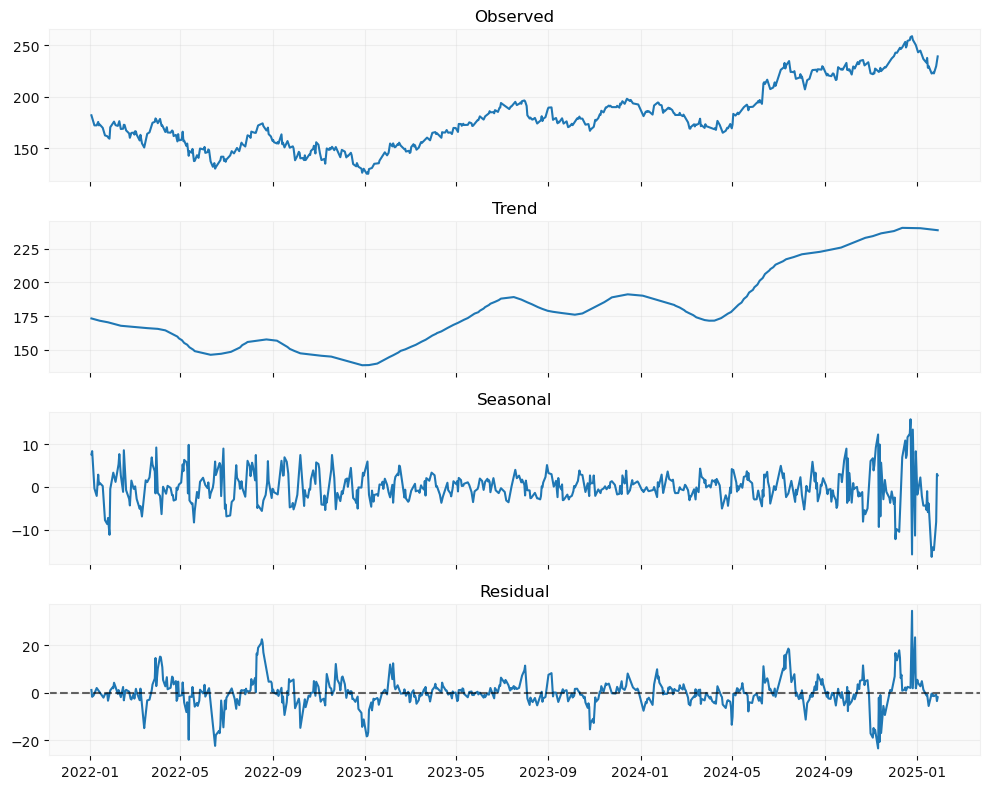

In [113]:
plot_decompose_classical(decompose_stl)

In [117]:
from __future__ import annotations

from typing import Mapping, Sequence, Optional
import pandas as pd
import matplotlib.pyplot as plt


def plot_decompose_classical(
    components: Mapping[str, pd.Series],
    *,
    order: Optional[Sequence[str]] = None,
    title: Optional[str] = None,
    figsize_base: tuple[int, int] = (10, 2),
    style: Optional[str] = None,
    show: bool = True,
    save_path: Optional[str] = None,
) -> plt.Figure:
    """
    Plot classical time-series decomposition components.

    Parameters
    ----------
    components : Mapping[str, pd.Series]
        Decomposition components (observed, trend, seasonal, residual).

    order : Sequence[str], optional
        Explicit order of components.

    title : str, optional
        Figure title.

    figsize_base : tuple[int, int]
        Base width and per-component height.

    style : str, optional
        Matplotlib style (e.g. 'seaborn-v0_8', 'ggplot').

    show : bool
        Whether to display the plot.

    save_path : str, optional
        Path to save the figure.

    Returns
    -------
    matplotlib.figure.Figure
    """

    # --------------------------------------------------
    # 1️⃣ Validation
    # --------------------------------------------------
    if not components:
        raise ValueError("Components dictionary is empty")

    if not all(isinstance(v, pd.Series) for v in components.values()):
        raise TypeError("All components must be pandas Series")

    order = order or list(components.keys())
    missing = set(order) - set(components.keys())
    if missing:
        raise ValueError(f"Missing components: {missing}")

    # --------------------------------------------------
    # 2️⃣ Styling (optional)
    # --------------------------------------------------
    if style:
        plt.style.use(style)

    n = len(order)
    figsize = (figsize_base[0], figsize_base[1] * n)

    fig, axes = plt.subplots(
        nrows=n,
        ncols=1,
        sharex=True,
        figsize=figsize,
    )

    if n == 1:
        axes = [axes]

    # --------------------------------------------------
    # 3️⃣ Plot components
    # --------------------------------------------------
    for ax, name in zip(axes, order):
        series = components[name]

        ax.plot(series.index, series.values, linewidth=1.5)
        ax.set_title(name.capitalize())
        ax.grid(True, alpha=0.3)

        # Residual reference line
        if name.lower() == "residual":
            ax.axhline(0, linestyle="--", color="black", alpha=0.6)

    if title:
        fig.suptitle(title, fontsize=14, y=1.02)

    fig.tight_layout()

    # --------------------------------------------------
    # 4️⃣ Output control
    # --------------------------------------------------
    if save_path:
        fig.savefig(save_path, dpi=150, bbox_inches="tight")

    if show:
        plt.show()
    else:
        plt.close(fig)

    return fig


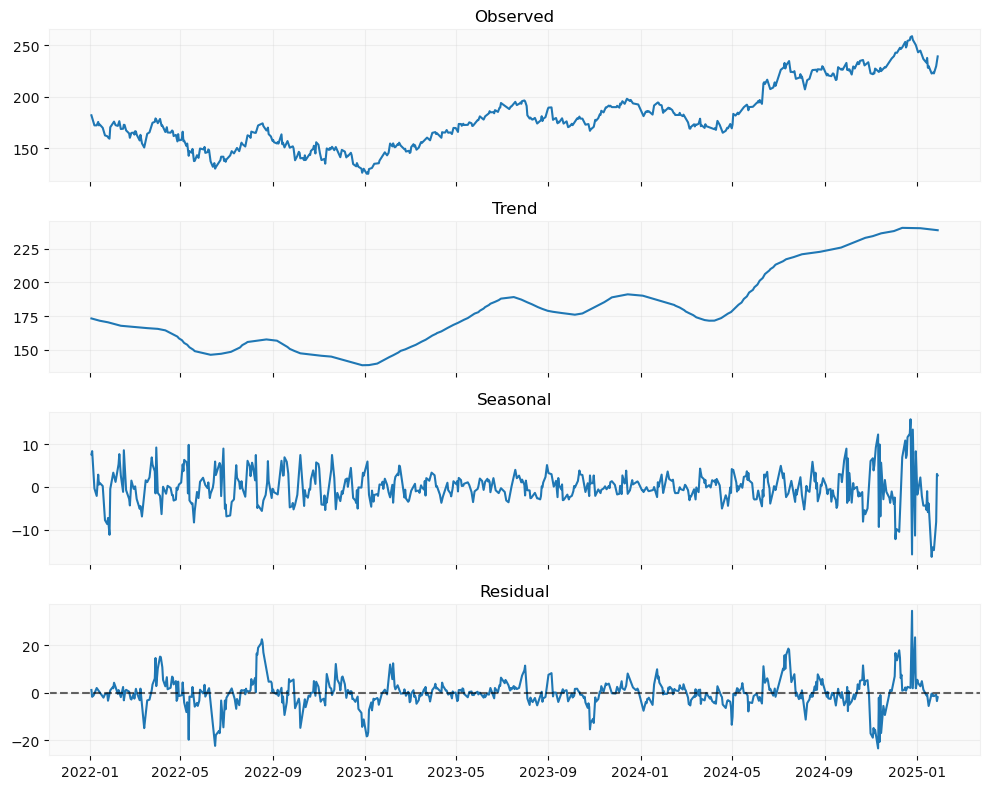

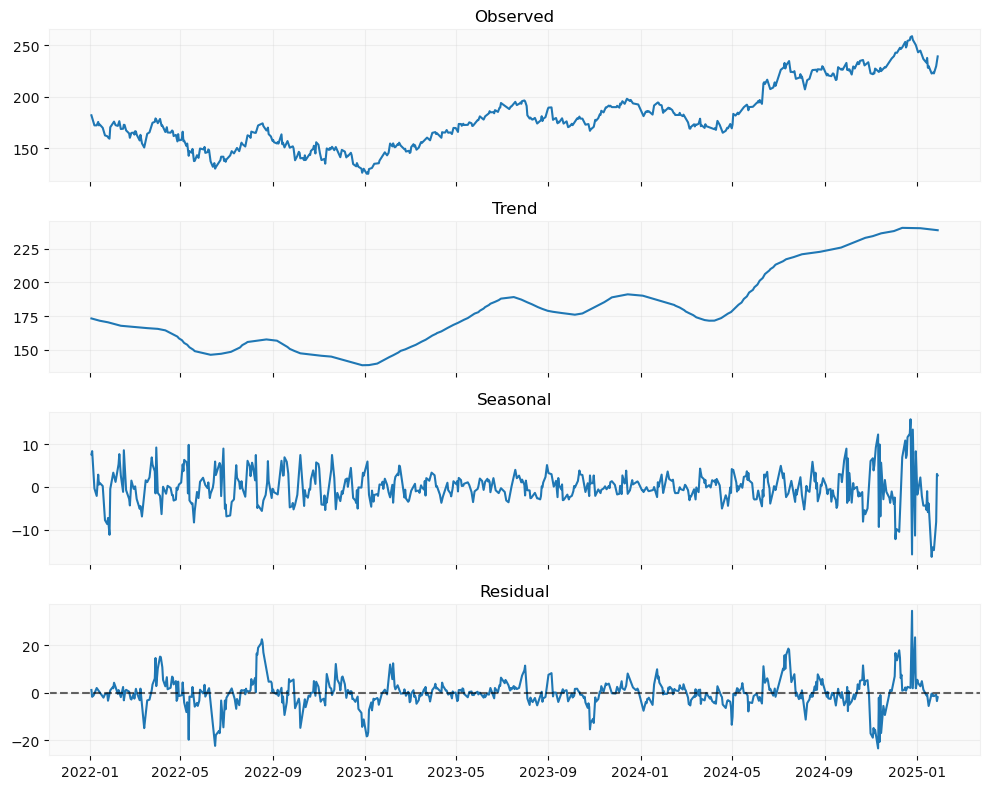

In [118]:
plot_decompose_classical(decompose_stl)


## Sationarity check

AD-FULLER TEST

Null Hypothesis: Non Stationary if ADF statistics <  Critical Value

In [114]:
from statsmodels.tsa.stattools import adfuller

In [115]:
adf_test = adfuller(data['Close'])

In [116]:
adf_test

(np.float64(-0.6190652571179127),
 np.float64(0.8666156059403963),
 0,
 770,
 {'1%': np.float64(-3.4388710830827125),
  '5%': np.float64(-2.8653008652386576),
  '10%': np.float64(-2.568772659807725)},
 np.float64(3734.3137207256063))

The Augmented Dickey-Fuller (ADF) test is a statistical test used to determine if a time series is stationary or not. The components of the ADF test result are:

1. *Test Statistic*: `np.float64(-0.6190652571179127)`
    - This is the value of the ADF test statistic, which is used to determine the presence of a unit root (i.e., non-stationarity) in the time series.
2. *p-value*: `np.float64(0.8666156059403963)`
    - This is the probability of observing the test statistic (or a more extreme value) assuming that the null hypothesis (i.e., the time series is non-stationary) is true. A high p-value indicates that the time series is likely non-stationary.
3. *Lags Used*: `0`
    - This is the number of lags used in the ADF test regression.
4. *Number of Observations*: `770`
    - This is the number of observations used in the ADF test.
5. *Critical Values*: `{'1%': np.float64(-3.4388710830827125), '5%': np.float64(-2.8653008652386576), '10%': np.float64(-2.568772659807725)}`
    - These are the critical values for the ADF test statistic at different significance levels (1%, 5%, and 10%). These values can be used to determine the significance of the test result.
6. *IC Best*: `np.float64(3734.3137207256063)`
    - This is the value of the information criterion (IC) used to select the optimal lag length. In this case, it's likely the Akaike Information Criterion (AIC) or the Bayesian Information Criterion (BIC).

Interpretation:

- If the p-value is less than a chosen significance level (e.g., 0.05), we reject the null hypothesis and conclude that the time series is likely stationary.
- If the test statistic is less than the critical value at a chosen significance level, we reject the null hypothesis and conclude that the time series is likely stationary.

In this case, the p-value is high (0.8666), indicating that the time series is likely non-stationary.

---

The correct interpretation is:

- Null Hypothesis: The time series is non-stationary (i.e., it has a unit root).
- Alternative Hypothesis: The time series is stationary.
- If ADF Statistic < Critical Value, we reject the Null Hypothesis and conclude that the time series is likely stationary.
- If ADF Statistic > Critical Value, we fail to reject the Null Hypothesis and conclude that the time series is likely non-stationary.

So, the decision rule is:

- ADF Statistic < Critical Value → Reject Null Hypothesis → Time series is likely stationary.
- ADF Statistic > Critical Value → Fail to reject Null Hypothesis → Time series is likely non-stationary.

In your example, the ADF Statistic (-0.619) is greater than the Critical Values (e.g., -3.438 for 1%, -2.865 for 5%, etc.), so we fail to reject the Null Hypothesis and conclude that the time series is likely non-stationary. This is consistent with the high p-value (0.8666).

## KPSS Test

In [119]:
from statsmodels.tsa.stattools import kpss

In [120]:
kpss_test = kpss( data['Close'], regression='ct')
kpss_test

/var/folders/cf/zzb7dtxj31d85f3kbl0p673m0000gq/T/ipykernel_22257/3133763447.py:1: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_test = kpss( data['Close'], regression='ct')


(np.float64(0.5018273451008964),
 np.float64(0.01),
 17,
 {'10%': 0.119, '5%': 0.146, '2.5%': 0.176, '1%': 0.216})

The warning message indicates that the test statistic is outside the range of p-values available in the look-up table, and the actual p-value is smaller than the p-value returned.

The KPSS test result is:

- *Test Statistic*: `np.float64(0.5018273451008964)`
- *p-value*: `np.float64(0.01)`
- *Lags Used*: `17`
- *Critical Values*: `{'10%': 0.119, '5%': 0.146, '2.5%': 0.176, '1%': 0.216}`

Interpretation:

- Null Hypothesis: The time series is stationary (or trend-stationary).
- Alternative Hypothesis: The time series is non-stationary.
- Since the p-value is 0.01, which is less than the typical significance level (e.g., 0.05), we reject the Null Hypothesis and conclude that the time series is likely non-stationary.

Note that the test statistic (0.5018) is greater than the critical values at all significance levels, which also indicates that the time series is likely non-stationary.

The warning message suggests that the actual p-value might be even smaller than 0.01, so we're quite confident in rejecting the Null Hypothesis and concluding that the time series is non-stationary.

## Kolmorgov-Smirnov test K-S test

In [122]:
import numpy as np
from scipy import stats
import pandas as pd

# Load your stock data into a Pandas DataFrame
# df = pd.read_csv('your_stock_data.csv')

# Assume 'Close' is the column with closing prices
data = df['Close']

# Perform the K-S test against a normal distribution
stats.kstest(data, 'norm')

# Perform the K-S test against a log-normal distribution
stats.kstest(np.log(data), 'norm')

KstestResult(statistic=np.float64(0.99999931208249), pvalue=np.float64(0.0), statistic_location=np.float64(4.828473697652494), statistic_sign=np.int8(-1))

The K-S test result indicates that the data does not follow a normal distribution.

- *K-S Statistic (D)*: `np.float64(0.99999931208249)`
    - This value is very close to 1, indicating a large difference between the empirical distribution of the data and the normal distribution.
- *p-value*: `np.float64(0.0)`
    - This value is extremely small, indicating that the probability of observing a K-S statistic at least as extreme as the one observed, assuming that the data follows a normal distribution, is essentially zero.
- *statistic_location*: `np.float64(4.828473697652494)`
    - This value indicates the location where the maximum distance between the empirical distribution and the normal distribution occurs.
- *statistic_sign*: `np.int8(-1)`
    - This value indicates the direction of the difference between the empirical distribution and the normal distribution.

Given the extremely large K-S statistic and the very small p-value, we can confidently reject the null hypothesis that the data follows a normal distribution.

In other words, the stock price data is likely to be non-normally distributed. This is not surprising, as financial data often exhibits non-normal characteristics, such as skewness, kurtosis, and heavy tails.

You may want to consider alternative distributions, such as:

- Log-normal distribution
- Student's t-distribution
- Generalized hyperbolic distribution
- Stable distribution

to model the stock price data.

In [123]:
import numpy as np
from scipy import stats

# Log-normal distribution
log_data = np.log(data)
ks_lognorm = stats.kstest(log_data, 'norm')
print(ks_lognorm)

# Exponential distribution
ks_expon = stats.kstest(data, 'expon')
print(ks_expon)

# Uniform distribution
ks_uniform = stats.kstest(data, 'uniform')
print(ks_uniform)

KstestResult(statistic=np.float64(0.99999931208249), pvalue=np.float64(0.0), statistic_location=np.float64(4.828473697652494), statistic_sign=np.int8(-1))
KstestResult(statistic=np.float64(1.0), pvalue=np.float64(0.0), statistic_location=np.float64(125.0199966430664), statistic_sign=np.int8(-1))
KstestResult(statistic=np.float64(1.0), pvalue=np.float64(0.0), statistic_location=np.float64(125.0199966430664), statistic_sign=np.int8(-1))


The K-S test results indicate that the data does not follow any of the tested distributions (normal, log-normal, exponential, uniform).

- All p-values are extremely small (0.0), indicating that the probability of observing the data given the tested distributions is essentially zero.
- The K-S statistics are very large (close to 1), indicating a large difference between the empirical distribution of the data and the tested distributions.

This suggests that the stock price data is likely to be non-normal and may require alternative distributions or modeling approaches, such as:

- Heavy-tailed distributions (e.g., Student's t, stable distributions)
- Skewed distributions (e.g., skew-normal, skew-t)
- Mixture distributions (e.g., Gaussian mixture models)
- Non-parametric approaches (e.g., kernel density estimation)

Some possible next steps:

- Explore alternative distributions and test them using K-S or other goodness-of-fit tests.
- Use visualization tools (e.g., histograms, Q-Q plots) to understand the shape of the data.
- Consider using robust or non-parametric methods for analysis and modeling.

Given the results, it's likely that the data is quite different from the standard distributions, so exploring alternative approaches may be necessary. 📊